In [1]:
from ase.build import bulk

si = bulk('Si', 'diamond', 5.48)

In [2]:
from gpaw import GPAW, PW, FermiDirac

calc = GPAW(mode=PW(400),
            xc='PBE',
            kpts=(8, 8, 8),
            random=True,
            occupations=FermiDirac(0.01),
            txt='Si_gs.txt')
si.set_calculator(calc)
si.get_potential_energy()
calc.write('Si_gs.gpw')

In [3]:
from gpawdev import band_gap

bandgap = band_gap(calc)
e=calc.get_potential_energy()
ef = calc.get_fermi_level()

print(f'E = {e:.4f} eV, Ef = {ef:.3f} eV')

Band gap: 0.8609 eV
E = -10.7988 eV, Ef = 5.631 eV


In [4]:
nbands = 8
calc = GPAW('Si_gs.gpw',
            fixdensity=True,
            nbands=24,
            symmetry='off')

In [5]:
cell=calc.atoms.get_cell(complete=True)
bp=cell.bandpath('WLGXWK',npoints=60)
kpts=bp.kpts
(x, X, labels) = bp.get_linear_kpoint_axis()

print('kpts:')
print(kpts)
print('x:')
print(x)
print('X:')
print(X)
print('labels:')
print(labels)

kpts:
[[0.5        0.25       0.75      ]
 [0.5        0.27272727 0.72727273]
 [0.5        0.29545455 0.70454545]
 [0.5        0.31818182 0.68181818]
 [0.5        0.34090909 0.65909091]
 [0.5        0.36363636 0.63636364]
 [0.5        0.38636364 0.61363636]
 [0.5        0.40909091 0.59090909]
 [0.5        0.43181818 0.56818182]
 [0.5        0.45454545 0.54545455]
 [0.5        0.47727273 0.52272727]
 [0.5        0.5        0.5       ]
 [0.46666667 0.46666667 0.46666667]
 [0.43333333 0.43333333 0.43333333]
 [0.4        0.4        0.4       ]
 [0.36666667 0.36666667 0.36666667]
 [0.33333333 0.33333333 0.33333333]
 [0.3        0.3        0.3       ]
 [0.26666667 0.26666667 0.26666667]
 [0.23333333 0.23333333 0.23333333]
 [0.2        0.2        0.2       ]
 [0.16666667 0.16666667 0.16666667]
 [0.13333333 0.13333333 0.13333333]
 [0.1        0.1        0.1       ]
 [0.06666667 0.06666667 0.06666667]
 [0.03333333 0.03333333 0.03333333]
 [0.         0.         0.        ]
 [0.02941176 0.       

In [6]:
import numpy as np

calc.set(kpts=kpts)
calc.get_potential_energy()
e_kn = np.array([calc.get_eigenvalues(k) for k in range(len(kpts))])

print('e_kn:')
print(e_kn)

e_kn:
[[-2.52647054 -2.52646669  1.31284303 ... 28.49221263 32.37882713
  32.45526121]
 [-2.81801726 -2.24432167  1.13175687 ... 29.05986993 31.98328354
  33.07803158]
 [-3.10328351 -1.99395577  1.03832438 ... 29.64944395 31.32436733
  31.62187549]
 ...
 [-3.04692493 -2.12003076  0.91271699 ... 28.30794779 30.19078223
  30.73829076]
 [-3.08179494 -2.1037082   0.88510637 ... 27.8837475  30.09137366
  30.76514419]
 [-3.09342303 -2.09862456  0.87587975 ... 27.83577543 30.06985882
  30.78475963]]


In [7]:
e_kn -= ef
emin = e_kn.min() - 1.0
emax = e_kn[:, nbands].max() + 1.0

print(f'Emin = {emin:.4f} eV, Emax = {emax:.4f} eV')

Emin = -13.3568 eV, Emax = 11.8367 eV


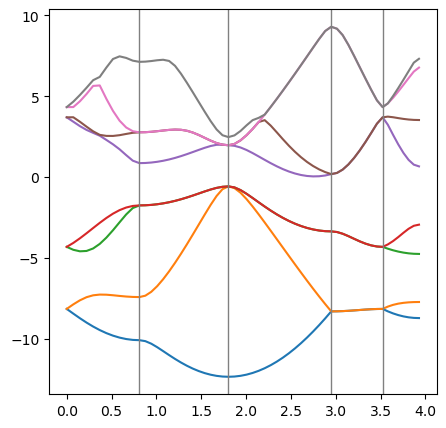

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5.0, 5.0))

for n in range(nbands):
    ax.plot(x, e_kn[:, n])
for p in X[1:-1]:
    ax.axvline(p, color='gray', linewidth=1.0)